During World War II, the Allies were curious to estimate the total number of tanks produced by Germany. 
Conventional intelligence methods were highly unreliable. 
Statisticians, however, devised an inventive approach: 
they estimated the unknown population size $N$ using only the serial numbers of captured tanks. 
This problem, known as the $\textbf{German Tank Problem}$, demonstrates how statistical estimation can outperform traditional intelligence gathering.

## Problem Formulation: German Tank Problem

**Assumptions:**

- Each tank has a unique serial number (index).
- Index range: $1, 2, \dots, N$ (where $N$ is unknown).
- We observe a simple random sample of size $K$ **without replacement**.
- The sample is denoted as $X_1, X_2, \dots, X_K$.

**Sampling Distribution:**

$$(X_1, \dots, X_K) \sim \text{Uniform over all } \binom{N}{K} \text{ subsets of } \{1,\dots,N\}$$

**Objective:**

$$\text{Find an estimator } \hat{N} = f(X_1, \dots, X_K) \text{ such that } \hat{N} \approx N.$$

**Common Estimators to Compare:**

$$\hat{N}_{\text{MLE}} = \max(X_1, \dots, X_K)$$

$$\hat{N}_{\text{MVUE}} = \max(X_1, \dots, X_K) \cdot \left(1 + \frac{1}{K}\right) - 1$$

$$\hat{N}_{\text{MOM}} = 2 \cdot \bar{X} - 1$$

In [1]:
# Import modules
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown as md

N_real: the true number of tanks `(assumed for simulation purposes)`.

In [2]:
N_real = 1000

sample_sizes: assumed sample sizes (k) for each simulation round

In [3]:
sample_sizes = [5, 10, 20, 50, 100]

n_simulations: number of iterations for simulation

In [4]:
n_simulations = 1000

Implementation of the three named estimators `(MLE, MVUE, MOM)`

In [5]:
def mle(sample):
    return max(sample)

In [6]:
def mvue(sample):
    k = len(sample)
    mvue_value = max(sample) * (1 + 1/k) - 1
    return mvue_value

In [7]:
def mom(sample):
    mean = np.mean(sample)
    MoM_value = 2 * mean - 1
    return MoM_value

results: dict - stores the estimated values for each `(sample_size, estimator)`

In [8]:
results = {size: {'mle':[], 'mvue':[], 'mom':[]} for size in sample_sizes}

Calculate the result of each estimator on $(X_1, ..., X_K)$ and save the results

In [9]:
for size in sample_sizes:
    for _ in range(n_simulations):

        sample = np.random.choice(range(1, N_real + 1), size=size, replace=False)

        results[size]['mle'].append(mle(sample))
        results[size]['mvue'].append(mvue(sample))
        results[size]['mom'].append(mom(sample))

mae_results: dict - maps (sample_size, estimator) tuples to their MAE values

In [10]:
mae_results = {size: {'MLE' : None, 'MVUE' : None, 'MOM' : None} for size in sample_sizes} 

Compute, store, and display the MAE for each (sample_size, estimator)

In [11]:
for size in sample_sizes:
    for method in ['mle', 'mvue', 'mom']:

        error = np.abs(np.array(results[size][method]) - N_real)
        mae = np.mean(error)
        mae_results[size][method.upper()] = mae
        print(f'size: {size}, {method.upper()}: MAE={mae:.1f}')

size: 5, MLE: MAE=170.1
size: 5, MVUE: MAE=129.7
size: 5, MOM: MAE=205.4
size: 10, MLE: MAE=89.1
size: 10, MVUE: MAE=68.8
size: 10, MOM: MAE=144.1
size: 20, MLE: MAE=46.2
size: 20, MVUE: MAE=35.7
size: 20, MOM: MAE=103.3
size: 50, MLE: MAE=19.3
size: 50, MVUE: MAE=14.2
size: 50, MOM: MAE=62.9
size: 100, MLE: MAE=8.9
size: 100, MVUE: MAE=6.8
size: 100, MOM: MAE=42.8


Visualize the stored MAE values from mae_results

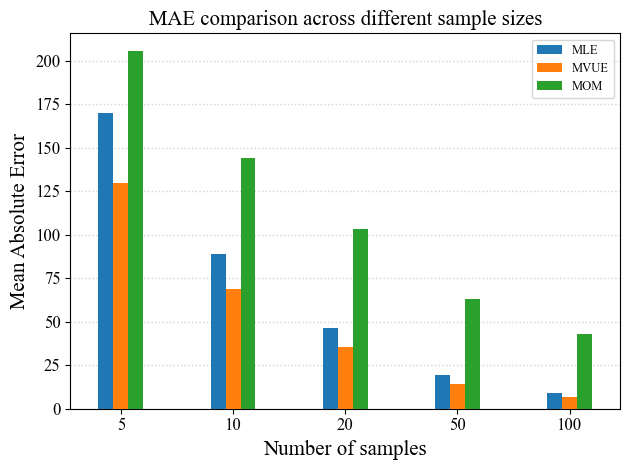

In [12]:
fig, ax = plt.subplots()

pd.DataFrame(mae_results, index=None).T.plot(kind='bar', width=0.4, ax=ax, zorder=3)

ax.set_xlabel('Number of samples', font='Times New Roman', fontsize=15)
ax.set_xticklabels(sample_sizes, rotation=0, font='Times New Roman', fontsize=12)

ax.set_title('MAE comparison across different sample sizes', font='Times New Roman', fontsize=15)

ax.set_ylabel('Mean Absolute Error', font='Times New Roman', fontsize=15)
ax.set_yticks(np.arange(0, 201, 25))
ax.set_yticklabels(np.arange(0, 201, 25),  font='Times New Roman', fontsize=12)

ax.grid(axis='y', linestyle=':', linewidth=1, color='lightgrey', zorder=0)

ax.legend(prop=dict(family='Times New Roman', size=9))

plt.tight_layout()

plt.savefig(r'../reports/figures/mae_comparison.png', dpi=500) 
plt.show()

In [13]:
# Saving the mae results
df_mae = pd.DataFrame(mae_results).T

df_mae.index.name = 'sample size'
df_mae.reset_index(inplace=True)

df_mae.to_csv(r'..\data\mae_result/mae_results.csv', index=False)

`The graph above shows that MVUE and MLE outperform MoM.`

Therefore, we conduct statistical tests only on these two estimators, using `K = 20`.

## Statistical Comparison of MVUE and MLE (K = 20)

We compared the absolute errors of MVUE and MLE using 1,000 simulations.

Most classic statistical tests (like t-test) assume that data are normally distributed.

To be confident in the validity of these tests, first we need to check normality. 

**Normality check (Shapiro-Wilk):**  

Examines the errors of the two estimators (MLE & MVUE).

If the p-value is less than 0.05, the normality hypothesis is rejected and we must use non-parametric tests

In [14]:
differences = np.array(results[20]['mvue']) - np.array(results[20]['mle'])

shapiro_stat, shapiro_p = stats.shapiro(differences)

In [15]:
print(f"Shapiro-Wilk test for normality:")
print(f"  statistic: {shapiro_stat:.3f}")
print(f"  p-value: {shapiro_p:.4f}")


if shapiro_p > 0.05:
    print('differences are normally distributed.')
else:
    print('differences are not normally distributed; it\'s better to use Wilcoxon test')

Shapiro-Wilk test for normality:
  statistic: 0.836
  p-value: 0.0000
differences are not normally distributed; it's better to use Wilcoxon test


Visualize the distribution of differences for better interpretation

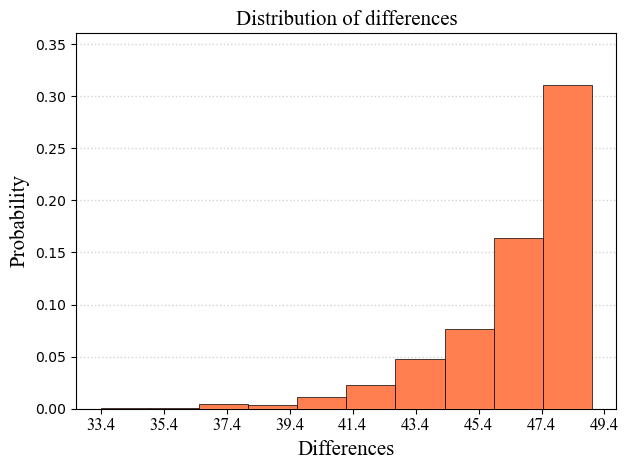

In [16]:
fig, ax = plt.subplots()

ax.hist(differences, bins=10, density=True, color='coral', linewidth=0.5, edgecolor='black', zorder=3)

ax.set_title('Distribution of differences', font='Times New Roman', fontsize=15)
ax.set_xlabel('Differences', font='Times New Roman', fontsize=15)
ax.set_ylabel('Probability', font='Times New Roman', fontsize=15)
ax.set_xticks(np.arange(differences.min(), differences.max() + 1, 2))
ax.set_xticklabels(np.round(np.arange(differences.min(), differences.max() + 1, 2), 1), font='Times New Roman', fontsize=12)

y_max = ax.yaxis.get_data_interval()[1]
ax.set_ylim(0, y_max + 0.05)
ax.grid(axis='y', linewidth=1, linestyle=':', color='lightgrey', zorder=0)

plt.tight_layout()

plt.savefig(r'../reports/figures/differences_distribution.png', dpi=500) 
plt.show()

**paired t-test**

This test examines the relationship between two sets of data.

$H_0$:
$\bar{d} = 0$ (the mean difference between paired observations is zero)

where $d_i = \text{error}_{MVUE,i} - \text{error}_{MLE,i}$

If p-value $> 0.05$, we conclude that the two estimators perform similarly.

Otherwise (p-value $< 0.05$), we conclude that the difference is statistically significant.

**Note**: Due to the Shapiro-Wilk test result (which rejected normality), we cannot rely  on the result of *paired t-test*

In [17]:
# If data were normally distributed:
mle_errors_20 = np.abs(np.array(results[20]['mle']) - N_real)
mvue_errors_20 = np.abs(np.array(results[20]['mvue']) - N_real)

t_stat, p_value = stats.ttest_rel(mvue_errors_20, mle_errors_20)

In [18]:
print(f"MVUE vs. MLE (sample size=20):")
print(f"  Mean error (MVUE): {np.mean(mvue_errors_20):.2f}")
print(f"  Mean error (MLE):  {np.mean(mle_errors_20):.2f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print('MVUE significantly has less error')
else:
    print('The difference is not significant')

MVUE vs. MLE (sample size=20):
  Mean error (MVUE): 35.70
  Mean error (MLE):  46.16
  t-statistic: -9.787
  p-value: 0.0000
MVUE significantly has less error


When the Shapiro-Wilk test rejects normality, the results of the t-test are not valid.  

Therefore, we use the non-parametric Wilcoxon signed-rank test instead.

This test does not assume any specific data distribution; it relies only on the orders and ranks of the data.

**Wilcoxon test**:

Compares the distributions of two related sets of data.

$H_0$: $\text{median}(d) = 0$ (the median difference between paired observations is zero)

where $d_i = \text{error}_{MVUE,i} - \text{error}_{MLE,i}$

Rejection of $H_0$ (p-value < 0.05) demonstrates that one estimator consistently performs better than the other.

In [19]:
mle_errors_20 = np.abs(np.array(results[20]['mle']) - N_real)
mvue_errors_20 = np.abs(np.array(results[20]['mvue']) - N_real)

wilcoxon_stat, wilcoxon_p = stats.wilcoxon(mvue_errors_20, mle_errors_20)

In [20]:
print(f"Wilcoxon signed-rank test:")
print(f"  statistic: {wilcoxon_stat:.1f}")
print(f"  p-value: {wilcoxon_p:.6f}")

if wilcoxon_p < 0.05:
    print("   Wilcoxon confirms: MVUE has significantly less error")
else:
    print("  No significant difference detected")

Wilcoxon signed-rank test:
  statistic: 156082.0
  p-value: 0.000000
   Wilcoxon confirms: MVUE has significantly less error


In addition to hypothesis tests, we can find a confidence interval for the median difference of errors using the bootstrap method.

**Bootstrap**

Bootstrap is a resampling method that works without any specific assumptions about the data distribution.

We construct a 95% confidence interval (CI) for the median difference.

- If the 95% CI **does not contain** 0, we conclude that the difference between the two estimators is statistically significant.
- If the 95% CI **contains** 0, we conclude that the difference is **not** statistically significant.

In [21]:
n_bootstrap = 10000
median_diffs = []

for _ in range(n_bootstrap):
    sample_idx = np.random.choice(len(mvue_errors_20), size=len(mvue_errors_20), replace=True)
    median_mvue = np.median(mvue_errors_20[sample_idx])
    median_mle = np.median(mle_errors_20[sample_idx])
    median_diffs.append(median_mvue - median_mle)

ci_lower = np.percentile(median_diffs, 2.5)
ci_upper = np.percentile(median_diffs, 97.5)

In [22]:
print(f"Bootstrap 95% CI for median difference (MVUE - MLE):")
print(f"  [{ci_lower:.2f}, {ci_upper:.2f}]")

if ci_lower <= 0 <= ci_upper:
    print("The difference is NOT statistically significant (CI contains zero).")
else:
    print("The difference IS statistically significant (CI does not contain zero).")

Bootstrap 95% CI for median difference (MVUE - MLE):
  [-4.90, 2.25]
The difference is NOT statistically significant (CI contains zero).


In [23]:
table = f"""
**Conclusion**

|Result/Test name|Shapiro-Wilk|Paired t-test|Wilcoxon|confidence interval
|---|:---:|:---:|:---:|:---:|
|p-value|{shapiro_p:.4f}|{p_value:.4f}|{wilcoxon_p:.4f}|contains 0: Yes|
|statistic|{shapiro_stat:.3f}|{t_stat:.3f}|{wilcoxon_stat:.3f}|[{ci_lower:.2f}, {ci_upper:.2f}]|
|interpretation|data are not normally distributed|the mean differences are statistically significant|One estimator consistently outperforms the other|median difference is NOT statistically significant|
|final result|-|MVUE (not reliable)|MVUE|No significant difference|
"""

In [24]:
md(table)


**Conclusion**

|Result/Test name|Shapiro-Wilk|Paired t-test|Wilcoxon|confidence interval
|---|:---:|:---:|:---:|:---:|
|p-value|0.0000|0.0000|0.0000|contains 0: Yes|
|statistic|0.836|-9.787|156082.000|[-4.90, 2.25]|
|interpretation|data are not normally distributed|the mean differences are statistically significant|One estimator consistently outperforms the other|median difference is NOT statistically significant|
|final result|-|MVUE (not reliable)|MVUE|No significant difference|


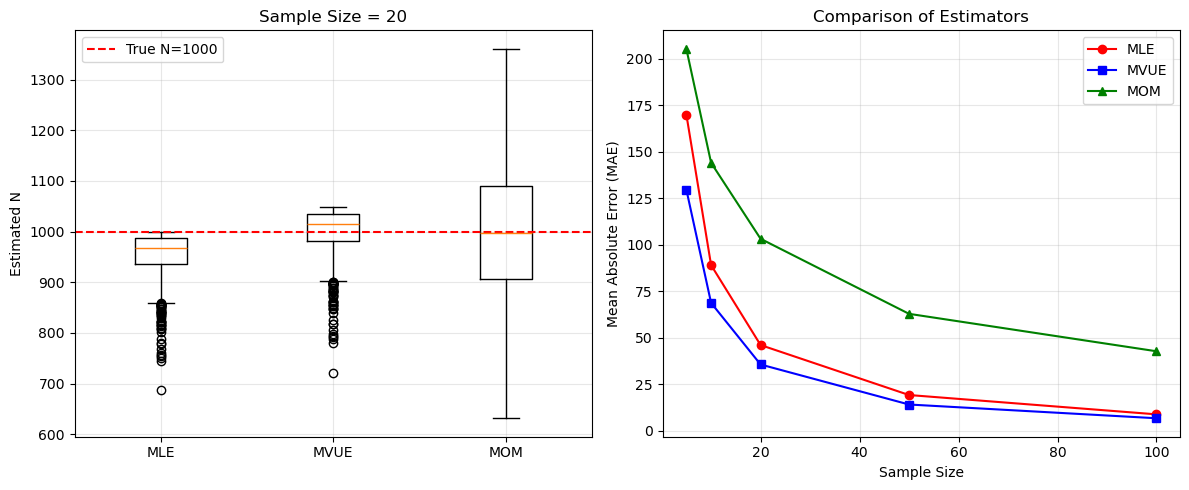

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

size = 20
axes[0].boxplot([results[size]['mle'], results[size]['mvue'], results[size]['mom']], 
                tick_labels=['MLE', 'MVUE', 'MOM'])
axes[0].axhline(y=N_real, color='r', linestyle='--', label=f'True N={N_real}')
axes[0].set_ylabel('Estimated N')
axes[0].set_title(f'Sample Size = {size}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


for method, color, marker in [('mle', 'red', 'o'), ('mvue', 'blue', 's'), ('mom', 'green', '^')]:
    mae_values = [np.mean(np.abs(np.array(results[size][method]) - N_real)) for size in sample_sizes]
    axes[1].plot(sample_sizes, mae_values, marker=marker, color=color, label=method.upper())

axes[1].set_xlabel('Sample Size')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].set_title('Comparison of Estimators')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/box_errors.png', dpi=500)
plt.show()

## Final Choice

Based on the statistical evidence:

- The **Shapiro-Wilk test** indicates that the data are not normally distributed, making the **paired t-test unreliable**.
- The **Wilcoxon signed-rank test** (which does not assume normality) shows a statistically significant difference between the two estimators (p < 0.001), with **MVUE consistently producing lower errors** than MLE.
- The **bootstrap confidence interval** for the median difference contains zero, meaning that the **median difference is not statistically significant**. However, this does not contradict the Wilcoxon result, because Wilcoxon is sensitive to the entire distribution (including outliers), while the median focuses only on the central value.

**Therefore, we conclude that MVUE performs better than MLE overall, especially in terms of mean error and distribution of errors.**  
For practical purposes, **MVUE is the recommended estimator** for the German Tank Problem, particularly for small to medium sample sizes.